# Hypothesis engines — status, results, and what each can honestly claim

**Notebook 05.** The five research channels (H1–H5), each with its freeze class and what it
has actually produced. **The pre-registration ledger is now frozen** — this notebook reads
its real state below and labels every claim accordingly.

LEDGER FROZEN at 2026-07-29T05:20:00+00:00
  h1_term_structure      freeze_class=X  status=exploratory
  h2_index_access        freeze_class=X  status=exploratory
  h3_letf_loop           freeze_class=X  status=exploratory
  h4_vol_decomposition   freeze_class=X  status=exploratory
  h5_quota_ledger        freeze_class=C  status=frozen
\nClass C = registered (H5). Class X = exploratory (H1-H4). Class P = empty (no prior commit).


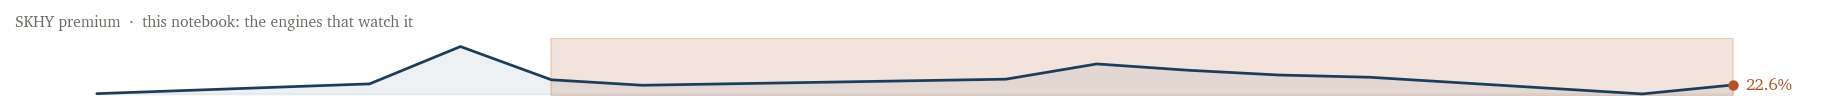

In [1]:
%matplotlib inline
import sys, subprocess, yaml, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
calls = yaml.safe_load((ROOT/"preregistration"/"calls.yaml").read_text())
print("LEDGER FROZEN at", calls.get("frozen_at"))
for h in ("h1_term_structure","h2_index_access","h3_letf_loop","h4_vol_decomposition","h5_quota_ledger"):
    print(f"  {h:22s} freeze_class={calls[h].get('freeze_class')}  status={calls[h]['status']}")
print("\\nClass C = registered (H5). Class X = exploratory (H1-H4). Class P = empty (no prior commit).")
from pipeline.viz import theme; theme.apply()
_pi = __import__("pipeline.measurement.premium", fromlist=["build_all_variants"]).build_all_variants("skhy")[0].series
theme.sparkline_header(_pi, highlight=("2026-07-15","2026-07-28"), label="SKHY premium  ·  this notebook: the engines that watch it");

## H5 — barrier-state monitor (Class C, **registered**)

The one pre-registered call. Its observable, live, with the scope limit on every output.

In [2]:
from hypotheses.h5_quota_ledger.monitor import status_report
print(status_report())

H5 — BARRIER-STATE LEDGER
skhynix_dr_headroom_capped  (US78392B2060)
  observations : 1   2026-07-15 .. 2026-07-15
  headroom     : 0
  flow         : no movement observed — level has never changed in sample
  ! headroom is ZERO — the barrier reads SEALED at this observation.
  ! single observation: KSD appears to publish only on change, so this is consistent with 'has not moved' rather than 'not published'. The control programme distinguishes the two.

skhynix_dr_headroom_legacy  (US78392B1070)
  observations : 1260   2010-03-31 .. 2026-07-28
  headroom     : 129,711,611
  flow         : 502 creation(s), 757 consumption(s)
  latest move  : +590

PUBLICATION CHECK
  PUBLISHING — control printed to 2026-07-28 while the capped programme's last print is 2026-07-15. The feed is live, so the capped programme has NOT MOVED. Barrier remains sealed by observation, not by absence of data.

CONTROL-PROGRAMME EPISODES ≥0.25% of level: 33

----------------------------------------------------------

The publication check is the substantive line: the capped programme's silence since
2026-07-15 is disambiguated by the control printing through 07-28 — so the barrier is
**sealed by observation, not by a dead feed.** The registered criterion carries an
INDETERMINATE branch for the case where headroom moves but no deposit clears, because
measured headroom is not the operative consent gate.

## H4 — realized variance decomposition (Class X, exploratory)

Exact log identity; the covariance terms reported, not folded away. The contrast between
pairs is the finding, not the SKHY level.

In [3]:
from hypotheses.h4_vol_decomposition.realized import compare_pairs
vd = compare_pairs()
vd[["pair","n","ann_vol_adr_pct","share_local","share_fx","share_pi","share_cov_local_pi","residual"]]

,pair,n,ann_vol_adr_pct,share_local,share_fx,share_pi,share_cov_local_pi,residual
0,skhy,11,184.22,0.5952,0.0017,0.7790,-0.3399,5.204170e-18
1,tsmc,2327,35.50,0.6352,0.0189,1.0077,-0.6963,2.168404e-19
2,baba,1592,49.44,0.9990,0.0002,0.9453,-0.9460,0.000000e+00


Premium variance is comparable to — for TSM slightly exceeds — total ADR variance, offset
by a strongly negative local-premium covariance: the premium **absorbs** local moves. BABA,
the fungible control, shows near-total cancellation (local 0.999, cov −0.946).

## M3 — convergence dynamics per regime class (PROVISIONAL)

Jordà local projections, HAC errors, SKHY forward-scored never fitted. **The deliverable
that gates the trade-sheet work.**

In [4]:
from pipeline.convergence.jorda import run_panel, metrics_table, score_skhy
res = run_panel()
metrics_table(res)

,regime,n_pairs,n_obs,horizon,rho,t_HAC,r2,n_eff,half_life_days,half_life_lo,half_life_hi,half_life_support,PROVISIONAL
0,fungible,1,1593,1,0.0381,1.27,0.0015,1592.0,1.0,NaN,1.0,sub_resolution,pending taxonomy ratification
1,fungible,1,1593,5,0.0387,1.39,0.0015,317.6,1.0,NaN,1.0,sub_resolution,pending taxonomy ratification
2,fungible,1,1593,20,0.0061,0.27,0.0000,78.7,1.0,NaN,1.0,sub_resolution,pending taxonomy ratification
3,one_way_constrained,1,2328,1,0.9387,128.98,0.8814,2327.0,331.3,143.3,unbounded,interpolated_underpowered,pending taxonomy ratification
4,one_way_constrained,1,2328,5,0.9203,74.04,0.8482,464.6,331.3,143.3,unbounded,interpolated_underpowered,pending taxonomy ratification
5,one_way_constrained,1,2328,20,0.8839,28.97,0.7799,115.4,331.3,143.3,unbounded,interpolated_underpowered,pending taxonomy ratification


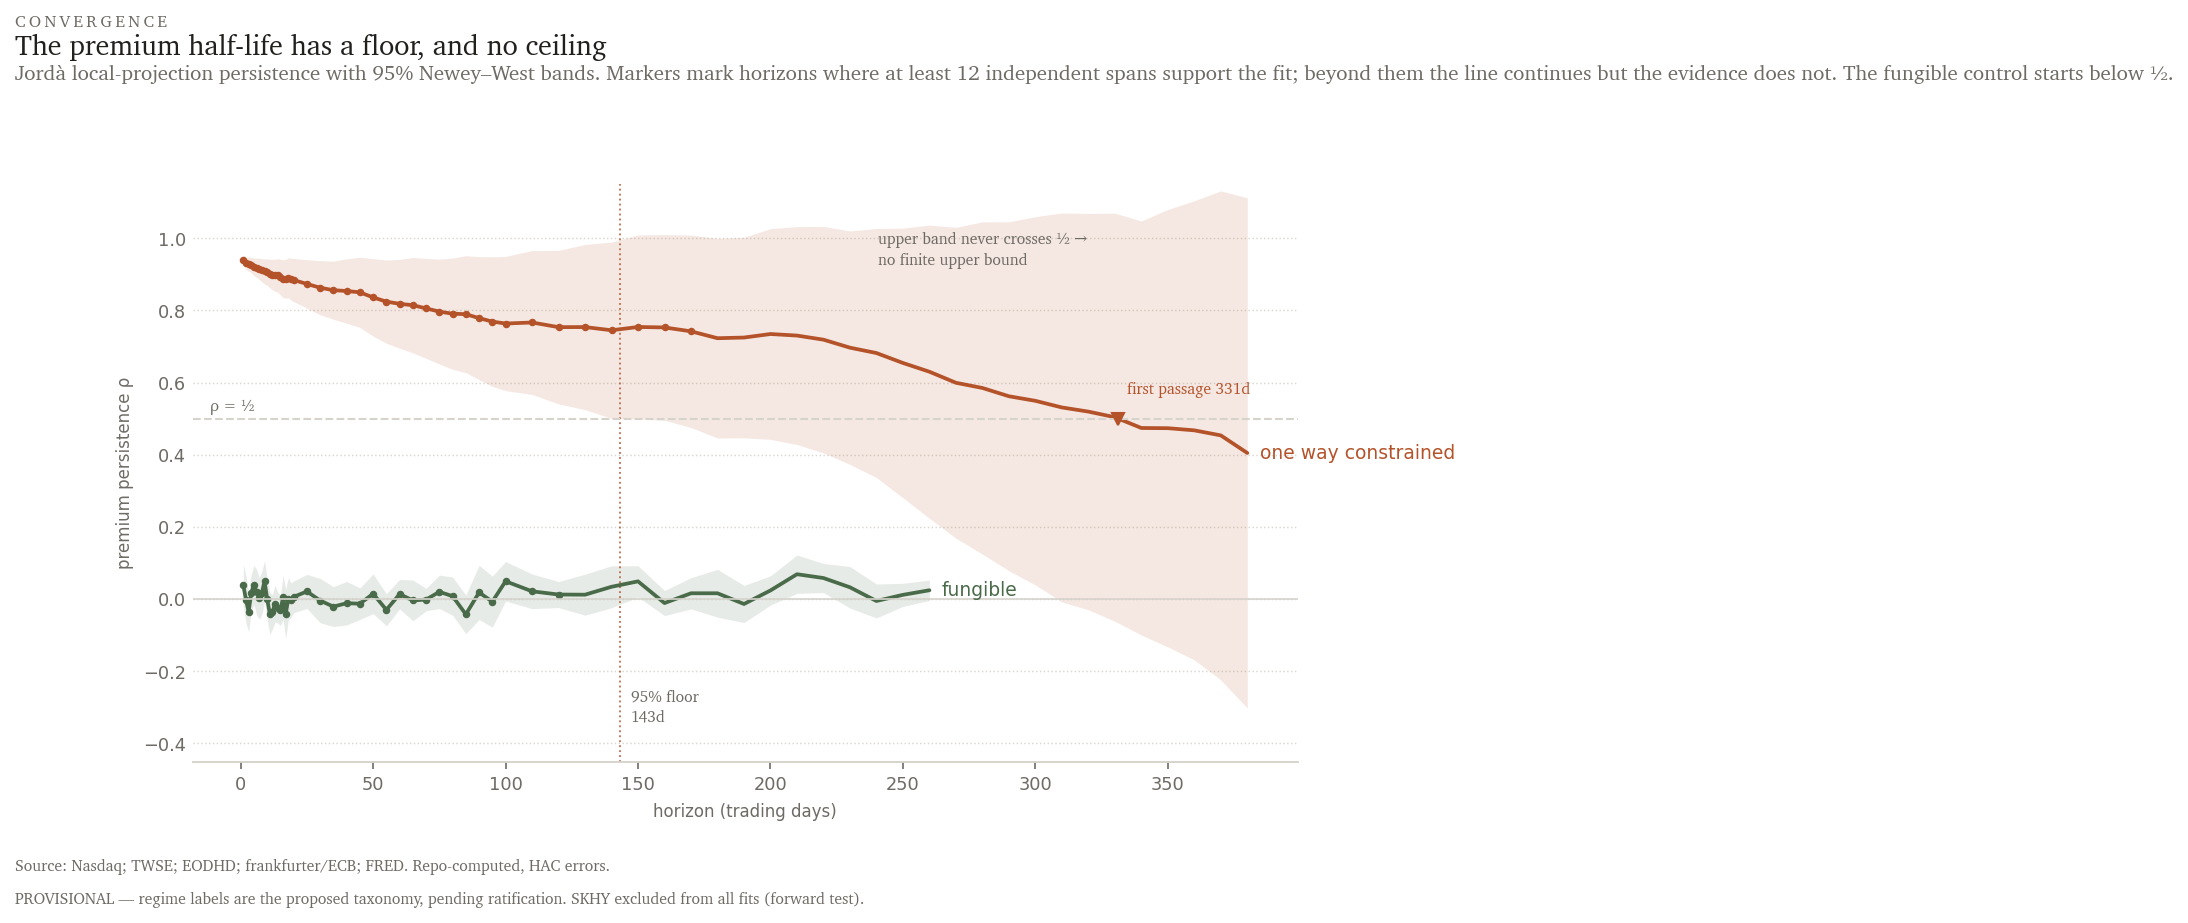

In [5]:
from pipeline.viz import figures
fig, ax = figures.g_convergence(res)
fig;

**Read as the reflected-process thesis in a convergence estimate.** `one_way_constrained`
(TSM): ρ ≈ 0.94 one day out, still 0.88 at twenty days, t-HAC 129 — persistence on a scale
of **months**. `fungible` (BABA): ρ ≈ 0.04, statistically insignificant — same-week noise
around parity. The identical estimator produces both.

**The half-life is an interval with an open end, and that is the S17 result.** Through S15
the window stopped at h=20, ρ never approached ½ inside it, and the reported ~227d came from
extrapolating an exponential fit. Extending to h=400 was meant to make the crossing
observable. It did — and the observation contradicted the extrapolation in the direction that
matters:

- First passage of ρ below ½ is at **h ≈ 331**, roughly **46% slower** than the extrapolation
  claimed. The extrapolation was optimistic.
- The 95% band's **upper edge never crosses ½ at any estimable horizon**, so there is **no
  finite upper bound** — these data do not reject a premium that never halves.
- The band's lower edge crosses at **h ≈ 143**, where coefficients are still identified. That
  floor is the defensible number.

So extending the horizon did not turn an extrapolation into an estimate. It turned a false
point into a **floor with an open tail** — which is what any quantity linear in holding
horizon, financing cost above all, has to be quoted against.

In [6]:
for regime, r in res.items():
    print(f"{regime:22s} half-life {r.hl.describe()}")
    print(f"{'':22s} {r.hl.method}")
    for n in r.notes: print("   !", n)
sk = score_skhy()
print(f"\\nSKHY: {sk['n_obs']} obs — {sk['out_of_support']}")
print(f"  {sk['note']}")
print(f"  resolution: {sk['resolution']}")

one_way_constrained    half-life 331d  [95% 143d .. unbounded]  interpolated_underpowered
                       first passage of ρ below ½ (in window)
   ! Half-life 331d is INSIDE the fitting window (h=380) — no longer an extrapolation — but it sits where only ~6 independent spans support it (threshold 12). The crossing is observed; it is not precisely located.
   ! NO FINITE UPPER BOUND. The upper 95% edge of ρ_h stays above ½ across every estimable horizon (to h=380), so the data do not reject a premium that never halves. Any quantity linear in holding horizon — financing cost above all — inherits an unbounded upper tail and must be quoted as a floor, never a point.
   ! Lower bound 143d is the FASTEST convergence consistent with the data at 95%, and it is the defensible number: it sits where the coefficients are still identified.
fungible               half-life 1d  [95% 0d .. 1d]  sub_resolution
                       ρ is below ½ at the shortest horizon (h=1) — half-life is unde

## H1, H2, H3 — status (all Class X, exploratory; data-blocked)

| | channel | blocker |
|---|---|---|
| **H1** | term-structure RV | no sanctioned listed-derivatives source landed |
| **H2** | synthetic index access | venue reframed (Eurex terminated); KRX night-session separability unverified |
| **H3** | LETF close-imbalance | **no landed AUM** — issuer pages are JS SPAs, the data-bearing Naver route is terms-withheld |

H3's rebalance-notional estimator has no AUM input, so its power analysis is moot until an
AUM series lands. This is data-blocked, not a null result — the distinction matters.

## What this notebook does not claim

Nothing here is a blind pre-event forward test — **Class P is empty** (no call predates the
2026-07-29 release on the record). H5 is registered post-earnings, pre-flow, with earnings
acknowledged as known context. The convergence table is a **two-regime contrast**, not a
four-regime sweep — the `two_way_headroom` middle is empty (India unavailable). All of this
is stated rather than smoothed.